# **Quantitative analysis**

### Import Libraries

In [ ]:
import sys
from pathlib import Path

# Add the project root to the Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

Using project root: c:\Users\teMelkishi\Desktop\projects\tenx\projects\news-driven-stock-analysis


In [ ]:
import talib
import numpy as np
import matplotlib.pyplot as plt
import pynance as pn
from src.data_loader import load_data, handle_missing_values
from src.analysis import add_and_plot_moving_averages

In [ ]:
# Load the dataset
df = load_data('../../data/finance-data/AAPL.csv')
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08
2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09
2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09
2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08
2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08


In [ ]:
# Handle missing values
df = handle_missing_values(df)
df.head()

Checking for missing values...
Found 0 missing values. Filling with ffill.


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,7.460152e+08
2009-01-05,2.836553,2.884539,2.780469,2.794266,1.181608e+09
2009-01-06,2.789767,2.914229,2.770872,2.877641,1.289310e+09
2009-01-07,2.729484,2.774170,2.706990,2.753477,7.530488e+08
2009-01-08,2.780169,2.793666,2.700393,2.712090,6.735008e+08


## **Compute Technical Indicators with TA-Lib**

### Moving Averages (MA)

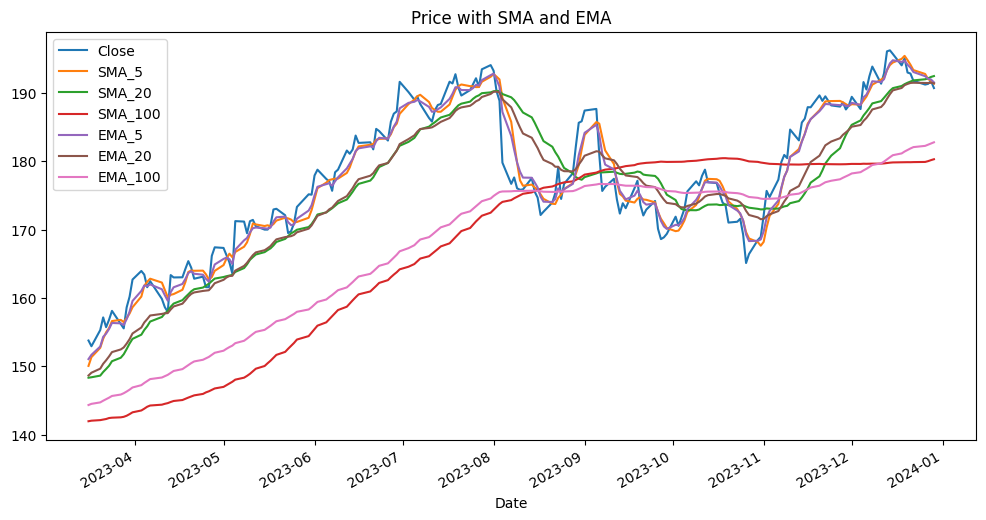

In [ ]:
windows = [5, 20, 100]
df = add_and_plot_moving_averages(df, windows)

### Relative Strength Index (RSI)

The **RSI** is a momentum oscillator (typically over a 14-day period) that measures the speed and magnitude of recent price changes on a scale from **0 to 100**.

- **RSI > 70** → often considered **overbought** (price may be stretched to the upside).
- **RSI < 30** → often considered **oversold** (price may be stretched to the downside).

#### Interpretation Notes
- Overbought/oversold levels are **signals of potential reversal**, not guarantees.
- In strong trends, RSI can remain above 70 or below 30 for extended periods.
- Combining RSI with trend context (e.g., moving averages) helps reduce false signals.

### MACD (Moving Average Convergence Divergence)

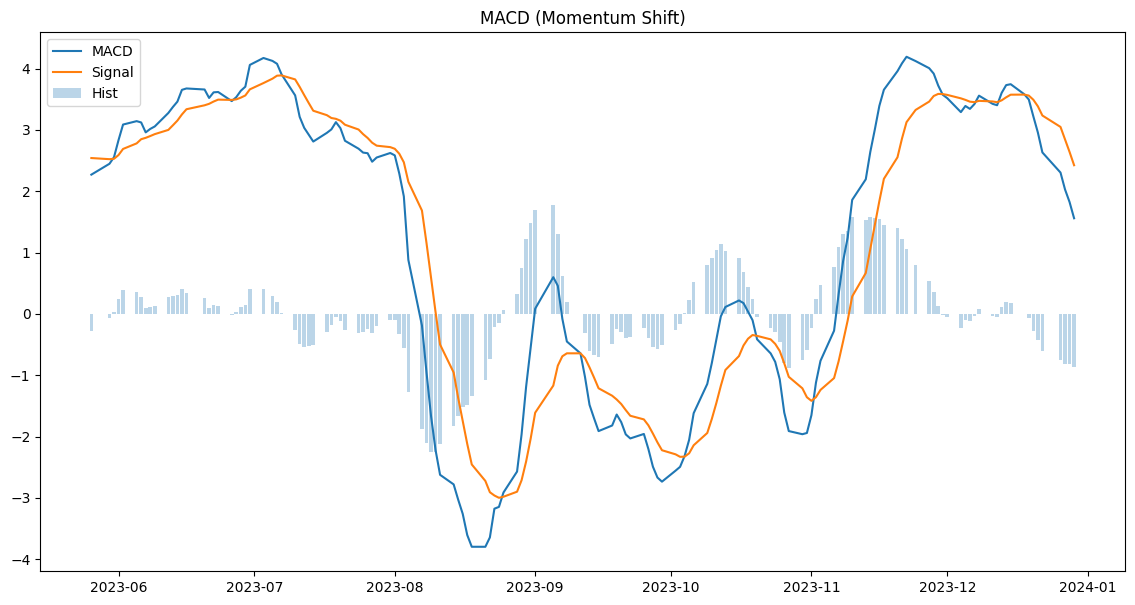

In [ ]:
df['macd'], df['macdsignal'], df['macdhist'] = talib.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

plt.figure(figsize=(14, 7))
plt.plot(df.index[-150:], df['macd'][-150:], label='MACD')
plt.plot(df.index[-150:], df['macdsignal'][-150:], label='Signal')
plt.bar(df.index[-150:], df['macdhist'][-150:], label='Hist', alpha=0.3)
plt.title("MACD (Momentum Shift)")
plt.legend()

## **Financial Metrics**

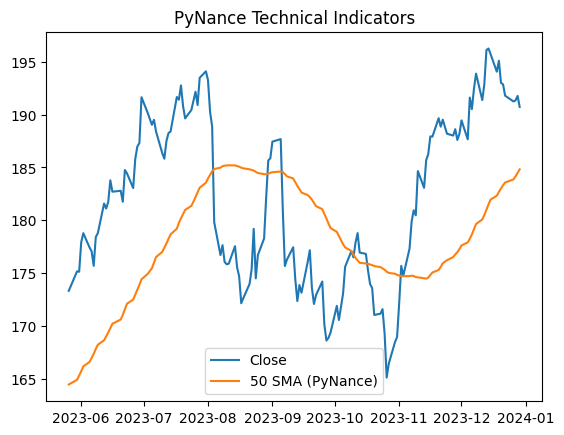

In [ ]:
try:
    df['SMA_50_pn'] = pn.tech.sma(df['Close'], window=50)
    plt.plot(df.index[-150:], df['Close'][-150:], label='Close')
    plt.plot(df.index[-150:], df['SMA_50_pn'][-150:], label='50 SMA (PyNance)')
    plt.title("PyNance Technical Indicators")
    plt.legend()
    plt.show()
except Exception as e:
    print(f"PyNance SMA error: {e}.")

In [ ]:
try:
    # PyNance-based moving averages
    df['PN_SMA_20'] = pn.tech.sma(df['Close'], window=20)
    df['PN_SMA_200'] = pn.tech.sma(df['Close'], window=200)

    # Returns and Performance
    df['Daily_Return'] = df['Close'].pct_change()
    df['Log_Return'] = np.log(df['Close']).diff()
    df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

    # Risk and Volatility Metrics
    df['Rolling_Volatility_20'] = df['Daily_Return'].rolling(window=20).std() * np.sqrt(252)
    df['Rolling_Sharpe_20'] = (
        df['Daily_Return'].rolling(window=20).mean() /
        df['Daily_Return'].rolling(window=20).std()
    ) * np.sqrt(252)

    # Portfolio Risk
    df['Drawdown'] = df['Close'] / df['Close'].cummax() - 1

    display(df[['Close', 'PN_SMA_20', 'PN_SMA_200', 'Daily_Return', 'Cumulative_Return',
                'Rolling_Volatility_20', 'Rolling_Sharpe_20', 'Drawdown']].tail())
except Exception as e:
    print(f"PyNance financial metrics error: {e}")

,Close,PN_SMA_20,PN_SMA_200,Daily_Return,Cumulative_Return,Rolling_Volatility_20,Rolling_Sharpe_20,Drawdown
Date,,,,,,,,
2023-12-22,191.788757,191.856618,176.609048,-0.005548,69.466884,0.144005,1.725082,-0.022765
2023-12-26,191.243912,192.018094,176.832686,-0.002841,69.266697,0.144498,1.554105,-0.025541
2023-12-27,191.342972,192.154308,177.047100,0.000518,69.303094,0.144240,1.321369,-0.025037
2023-12-28,191.768951,192.362839,177.253187,0.002226,69.459607,0.142446,2.013430,-0.022866
2023-12-29,190.728775,192.490633,177.452099,-0.005424,69.077426,0.144101,1.248231,-0.028166


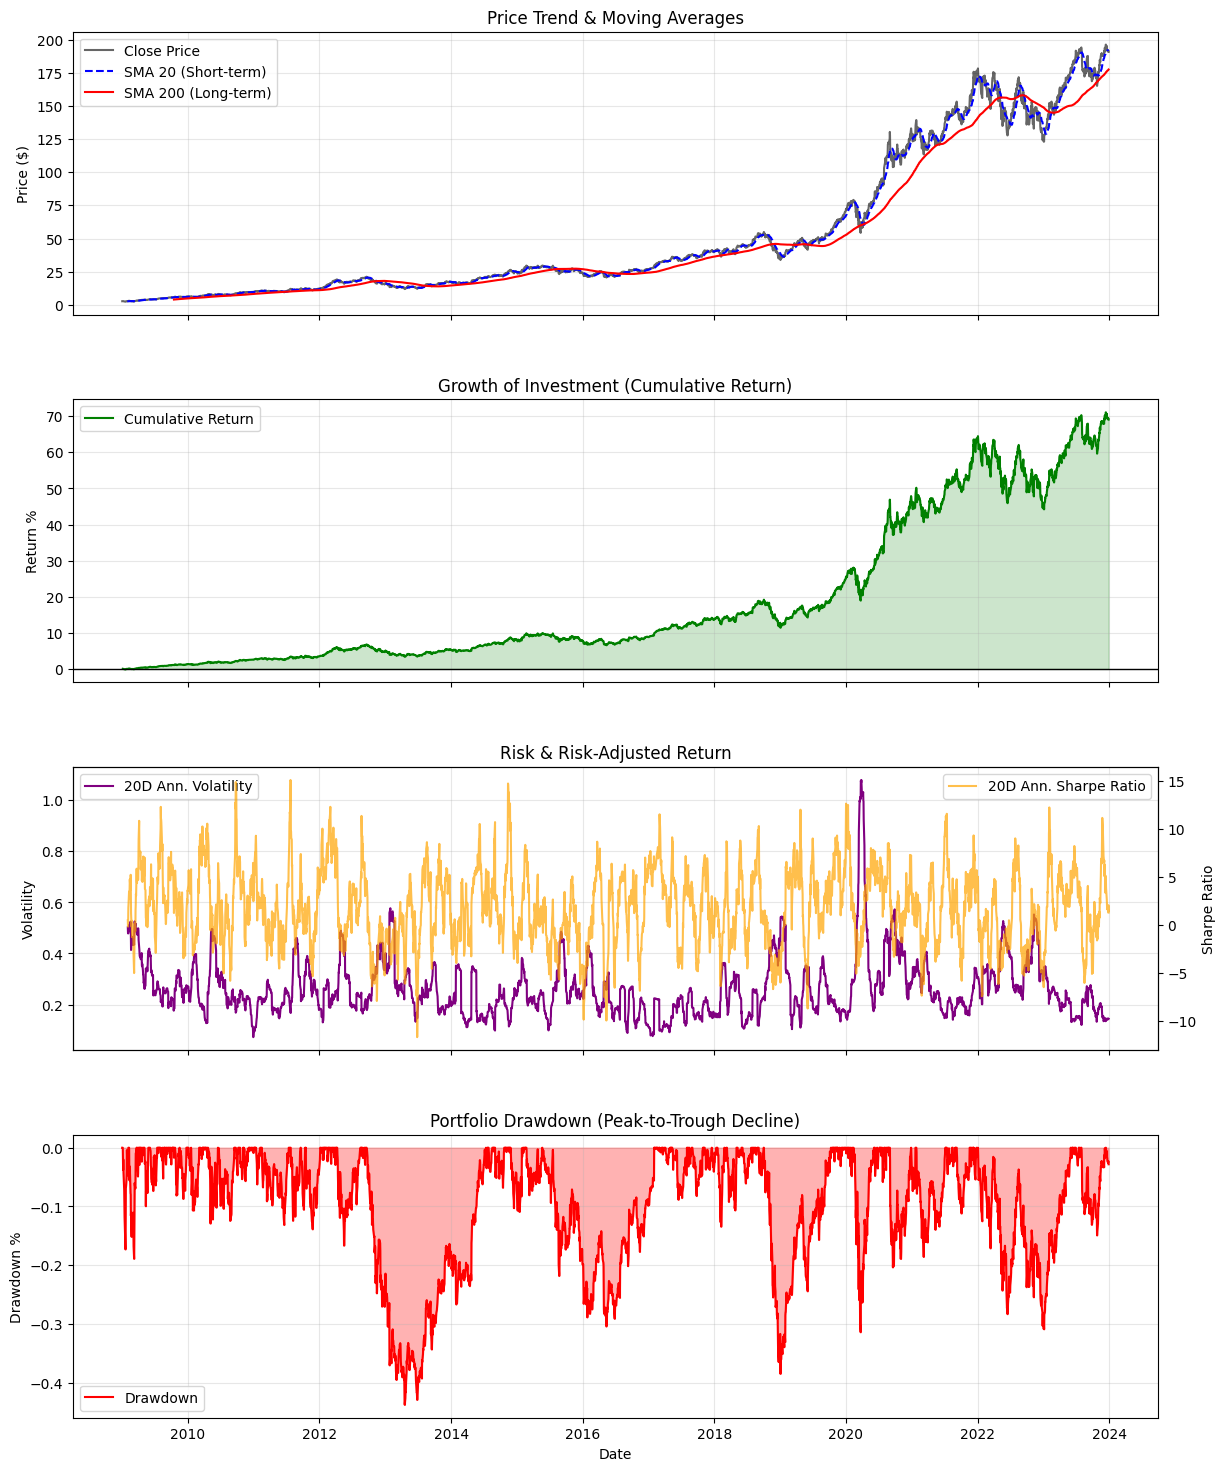

In [ ]:
# 1. Setup the figure and subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 18), sharex=True)
plt.subplots_adjust(hspace=0.3)

# --- Plot 1: Price and SMAs (Trend) ---
ax1.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.6)
ax1.plot(df.index, df['PN_SMA_20'], label='SMA 20 (Short-term)', color='blue', linestyle='--')
ax1.plot(df.index, df['PN_SMA_200'], label='SMA 200 (Long-term)', color='red')
ax1.set_title('Price Trend & Moving Averages')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Cumulative Return (Performance) ---
ax2.fill_between(df.index, df['Cumulative_Return'], color='green', alpha=0.2)
ax2.plot(df.index, df['Cumulative_Return'], color='green', label='Cumulative Return')
ax2.set_title('Growth of Investment (Cumulative Return)')
ax2.set_ylabel('Return %')
ax2.axhline(0, color='black', lw=1)
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: Risk Metrics (Volatility & Sharpe) ---
ax3.plot(df.index, df['Rolling_Volatility_20'], label='20D Ann. Volatility', color='purple')
ax3_twin = ax3.twinx()  # Create a second Y-axis for Sharpe
ax3_twin.plot(df.index, df['Rolling_Sharpe_20'], label='20D Ann. Sharpe Ratio', color='orange', alpha=0.7)
ax3.set_title('Risk & Risk-Adjusted Return')
ax3.set_ylabel('Volatility')
ax3_twin.set_ylabel('Sharpe Ratio')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# --- Plot 4: Drawdown (Risk Exposure) ---
ax4.fill_between(df.index, df['Drawdown'], 0, color='red', alpha=0.3)
ax4.plot(df.index, df['Drawdown'], color='red', label='Drawdown')
ax4.set_title('Portfolio Drawdown (Peak-to-Trough Decline)')
ax4.set_ylabel('Drawdown %')
ax4.set_xlabel('Date')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.show()

## **Visualize the Data**

#### Ensure RSI and MACD columns exist

In [ ]:
if 'RSI_14' not in df.columns:
    df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

if not {'macd', 'macdsignal', 'macdhist'}.issubset(df.columns):
    df['macd'], df['macdsignal'], df['macdhist'] = talib.MACD(
        df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
    )

#### Focus on recent data for readability

In [ ]:
plot_df = df.tail(300).copy()

### **Price Action and Moving Average Regimes**

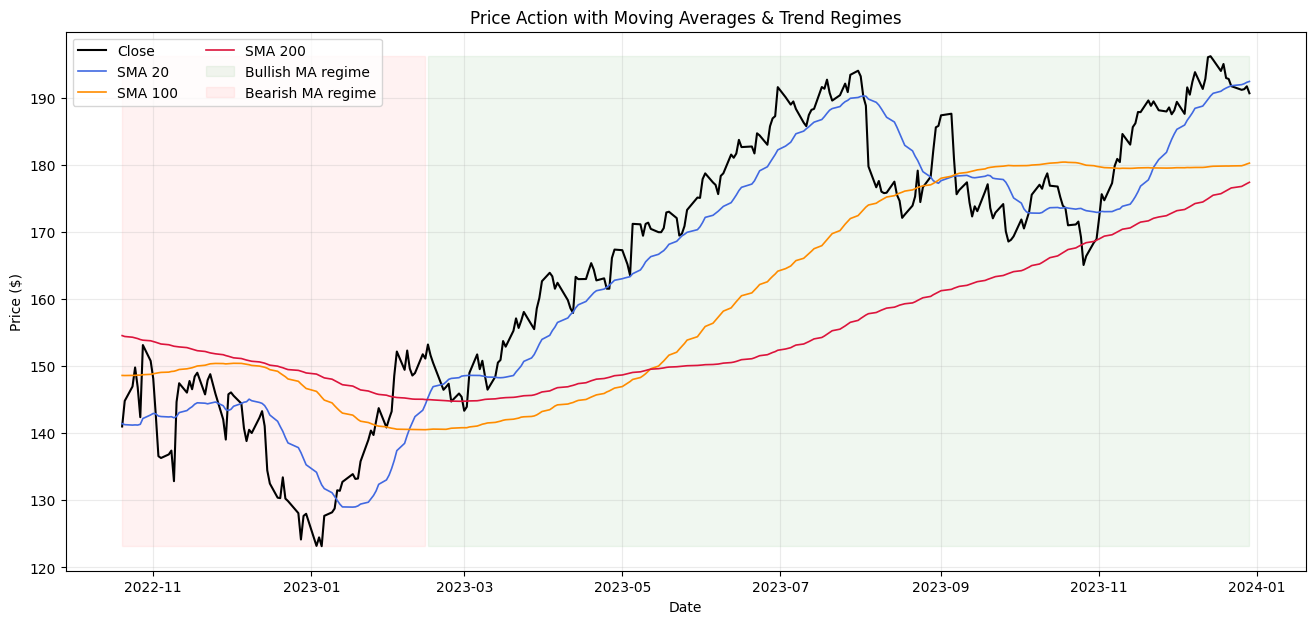

In [ ]:
plt.figure(figsize=(16, 7))

# Plot lines
plt.plot(plot_df.index, plot_df['Close'], label='Close', color='black', linewidth=1.5)
plt.plot(plot_df.index, plot_df['SMA_20'], label='SMA 20', color='royalblue', linewidth=1.2)
plt.plot(plot_df.index, plot_df['SMA_100'], label='SMA 100', color='darkorange', linewidth=1.2)
plt.plot(plot_df.index, plot_df['PN_SMA_200'], label='SMA 200', color='crimson', linewidth=1.2)

# Highlight trend regime (short MA vs long MA)
bull = plot_df['SMA_20'] >= plot_df['PN_SMA_200']
plt.fill_between(
    plot_df.index, plot_df['Close'].min(), plot_df['Close'].max(),
    where=bull, color='green', alpha=0.06, label='Bullish MA regime'
)
plt.fill_between(
    plot_df.index, plot_df['Close'].min(), plot_df['Close'].max(),
    where=~bull, color='red', alpha=0.05, label='Bearish MA regime'
)

plt.title('Price Action with Moving Averages & Trend Regimes')
plt.ylabel('Price ($)')
plt.xlabel('Date')
plt.grid(True, alpha=0.25)
plt.legend(loc='upper left', ncol=2)
plt.show()

### **RSI**

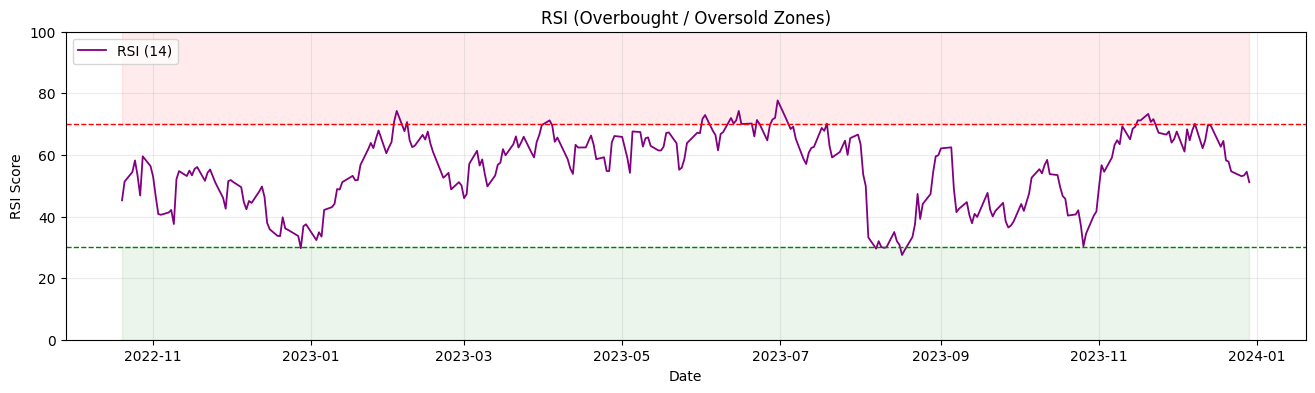

In [ ]:
plt.figure(figsize=(16, 4))

plt.plot(plot_df.index, plot_df['RSI_14'], color='purple', linewidth=1.3, label='RSI (14)')

# Overbought/Oversold thresholds
plt.axhline(70, color='red', linestyle='--', linewidth=1)
plt.axhline(30, color='green', linestyle='--', linewidth=1)

# Color shading
plt.fill_between(plot_df.index, 70, 100, color='red', alpha=0.08)
plt.fill_between(plot_df.index, 0, 30, color='green', alpha=0.08)

plt.ylim(0, 100)
plt.title('RSI (Overbought / Oversold Zones)')
plt.ylabel('RSI Score')
plt.xlabel('Date')
plt.grid(True, alpha=0.25)
plt.legend(loc='upper left')
plt.show()

### **MACD (Moving Average Convergence Divergence)**

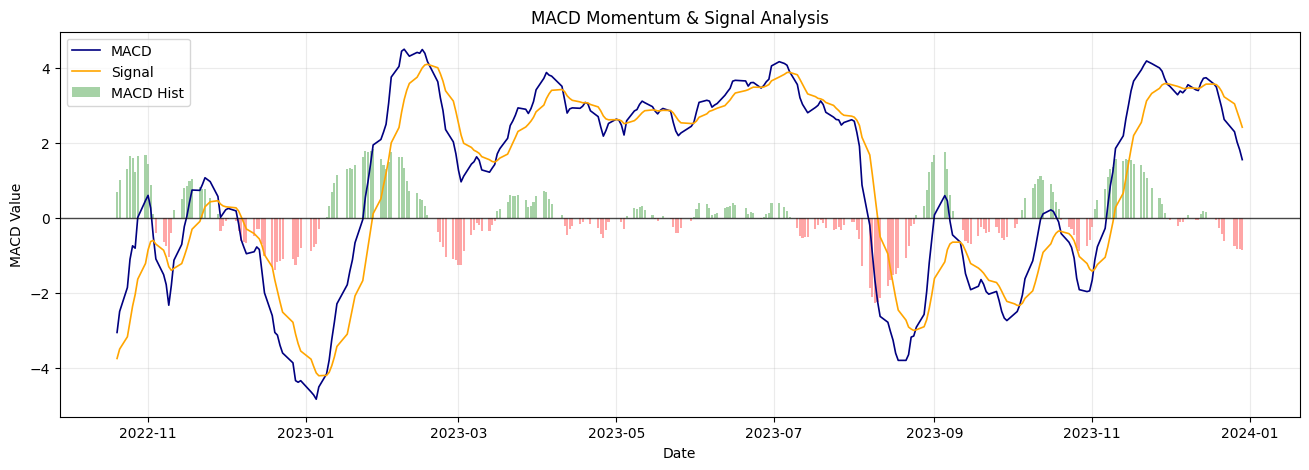

In [ ]:
plt.figure(figsize=(16, 5))

# Create histogram color array
hist_colors = np.where(plot_df['macdhist'] >= 0, 'green', 'red')

# Plot Histogram, MACD line, and Signal line
plt.bar(plot_df.index, plot_df['macdhist'], color=hist_colors, alpha=0.35, label='MACD Hist')
plt.plot(plot_df.index, plot_df['macd'], color='navy', linewidth=1.2, label='MACD')
plt.plot(plot_df.index, plot_df['macdsignal'], color='orange', linewidth=1.2, label='Signal')

# Zero line for neutral momentum
plt.axhline(0, color='black', linewidth=1, alpha=0.7)

plt.title('MACD Momentum & Signal Analysis')
plt.ylabel('MACD Value')
plt.xlabel('Date')
plt.grid(True, alpha=0.25)
plt.legend(loc='upper left')
plt.show()